In [ ]:
from jedi import create_environment

# các bước trong reinforcement learning

# tạo môi trường ban đầu
env = create_environment()
state = env.get_initial_state()

# trong vòng lặp môi trường
for i in range(n_iterations)
    # chọn các hành đôg chỉ dựa trên trạng thái hiện tại
    action = choose_action(state)

    # sau hành động môi trường cung cấp, se phan hoi lại dưới trạng thái ới, và phn thường
    state, reward = env.execute(action)

    # tác nhân sẽ nhận hiểu biết của mình với trạng thái, hành động vaf phần thưởng mới
    update_knowledge(state, action, reward)

In [3]:
# vi du ve discount
import numpy as np
expected_rewards = np.array([1,6,3])
discount_factor = 0.9
discounts = np.array([discount_factor ** i for i in range(len(expected_rewards))])
print("discount: ", discounts)

discounted_return = np.sum(expected_rewards * discounts)
print("discounted_return: ", discounted_return)

discount:  [1.   0.9  0.81]
discounted_return:  8.83


[ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


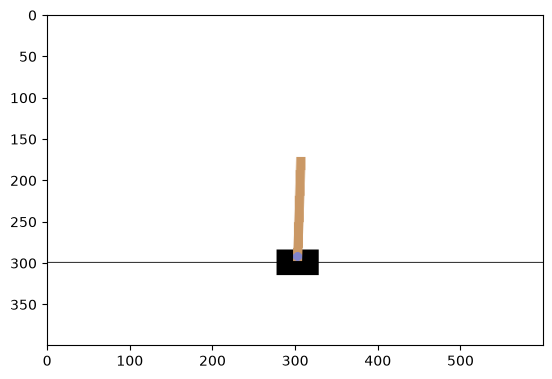

state:  [ 0.03104291  0.38306385  0.03102613 -0.5424507 ]
reward:  1.0
terminated:  False


In [19]:
import gymnasium as gym

# khoi tao moi truong
env = gym.make('CartPole', render_mode = 'rgb_array')
state,info = env.reset(seed=42) #tham so seed lam dam bao kha nang tai lap, quan sat
print(state)

# can phai truc quan hoa tro choi de agent co the hieu
import matplotlib.pyplot as plt

def render():
    state_image = env.render()
    plt.imshow(state_image)
    plt.show()

render()

#0 : moving left
#1: moving right

# de thuc thi hanh dong, chon env.step va truyen vao hanh dong da chon
action =  1
state,reward,terminated, truncated, info = env.step(action)
#terminated cho biet da cham trang thai hay chua, dat muc tieu hoac that bai
# truncated cho biet gioi han thoi gian da xyay ra hay khong
# info cho biet thoi gian chuan doan
# khoa nay tap trung vao 3 gia tri ban dau ne bo qua truncated va info trong ma ngoan
state, reward, terminated,_,_ = env.step(action)
print("state: ", state)
print("reward: ", reward)
print("terminated: ", terminated)


# Frozen lake

In [8]:
# action and state
import gymnasium as gym
env = gym.make('FrozenLake',is_slippery = True) # is_slippery = true có thể tạo ra chuyển động khó đoán như lên, xuống, trái phải
                                            # nếu đặt false nó là bất định
print(env.action_space) # xác định phạm vi hành động mà tác tự có thể thực hiện
# discrete(4) ở đây là 4 hành động mà tác tự có thể hành động được đánh số từ 0 tới 3
print(env.observation_space) #xác định các phạm vi trạng thái mà tác tự có thể gặp 
# discrete(16) ở đây là 16 ô mà tác tự có thể di chuyển vào, phạm vi hoạt động trong 16 ô

# để lấy số lượng hành động và trạng thái sử dụng env.action_space.n
print("so luong hanh dong: ", env.action_space.n)
print("so luong pham vi trang thai: ", env.observation_space.n)

Discrete(4)
Discrete(16)
so luong hanh dong:  4
so luong pham vi trang thai:  16


In [9]:
#grid world example: policy
# 0 left  1 down 2 right 3 up
import gymnasium as gym 
policy = {
    0:1, 1:2, 2:1,
    3:1, 4:3, 5:1,
    6:2, 7:3 
}

state, info = env.reset()
terminated = False
while not terminated:
    action = policy[state]
    state,reward,terminated,_,_=env.step(action)

In [17]:
# dinh nghia trang thai ket thuc va gamma
terminal_state = 8
gamma = 1
num_states = 9
#computing states-value
def compute_state_value(state):
    if state == terminal_state: # terminal_state: trang thai ket thuc
        return 0
    action = policy[state]
    _,next_state,reward,_ = env.unwrapper.P[state][action][0]
    return reward + gamma*compute_state_value(next_state)

V = {state:compute_state_value(state) for state in range(num_states)}

print(V)


#changing policis
policy_two = {
    0:2, 1:2, 2:1,
    3:2, 4:2, 5:1,
    6:2, 7:2
}
V_2 = {state:compute_state_value(state) for state in range(num_states)}
print(V_2)

AttributeError: 'TimeLimit' object has no attribute 'unwrapper'

In [ ]:
#assigment
# create environment with MyGridWorld, id moi truong rgb_array
import gymnasium as gym

env = gym.make('MyGridWorld',render_mode = 'rgb_array')
state,info = env.reset()

#define the policy: được định nghĩa là 1 dictionary ánh xạ từ mỗi trạng thái (state) sang hành động (action) theo như chính sách đã cho ở trong hình
policy = {
    0:2, 1:2, 2:1,
    3:1, 4:0, 5:0,
    6:2, 7:2
}


#complete the function
def compute_state_value(state):
    if state == terminal_state:
        return 0
    action = policy[state]
    _, next_state, reward,_ = env.unwrapped.P[state][action][0]
    return reward + gamma * compute_state_value(next_state)

state_values = {state: compute_state_value(state) for state in range(num_states) }



NameNotFound: Environment `MyGridWorld` doesn't exist.

In [ ]:
# tinh q value cho tat ca cac hanh dong tai 1 trang thai
def compute_q_value(state, action): # phai nhan vao trang thai de xem state_value tai trang thai bên cạnh, và nhận vào hành động để biết hành động gì
    if state == terminal_state: # nếu là trạng thái kết thúc thì return none
        return None
    _,next_state,reward,_ =env.unwrapped.P[state][action][0] # nnếu không phải kết thúc thì tính phần thưởng tức thời
    return reward + gamma * compute_state_value(next_state)


# sau đó định nghĩa 1 cái Q ánh xạ mọi cặp trạng thái hành động

Q ={(state, action): compute_q_value(state, action) 
    for state in range(num_states)
    for action in range(num_actions)}

print(Q)


# tao tu dien rộng để chọn lựa chọn và giá trị hành động tốt nhất trogn các trạng thái
improved_policy={}

for state in range(num_states - 1):
    max_action = max(range(num_actions), key = lambda action: Q[(state, action)]) # với mọi trạng thái tìm Q value lớn nhất
    improved_poliy[state] = max_action

print(improved_policy)


In [ ]:
# chinh sach moi GridWorld

policy = {
    0:1, 1:2, 2:1,
    3:1, 4:3, 5:1,
    6:2, 7:3
}

# để làm điều đó ta cần các hàm 
def policy_evaluation(policy):
    V = { state: compute_state_value(state, policy) for state  in range(num_states)}
    return V

def policy_improvemnet(policy):
    improved_policy = {s:0 for s in range(num_states - 1)} # khoi tao improved policy
    Q = {(state,action): compute_q_value(state, action, policy)
        for state in range(num_states) for action in range(num_actions)  }# dinh nghia 1 tu dien Q

    # voi moi trang thai
    for state in range(num_states -1 ):
        max_action = max(range(num_actions), key = lambda action: Q[(state, action)]) # tim trang thai co Q value lon nhat
        improved_policy[state] = max_action # cap nhat trang thai tot nhat vao improved_policy

    return improved_policy


def policy_iteration():
    policy = { 0:1,1:2,2:1, 3:1, 4:3, 5:1, 6:2, 7:3}  # bắt đầu bằng cách khởi tạo chính sách cần tối ưu
    # sau đó vào vòng lặp với 2 bước chính
    while True:
        V = policy_evaluation(policy)
        improved_policy = policy_improvement(policy)

        # nếu improved_policy giống y hệt chính sách cũ, nghĩa là chính sách đã hội tụ -> thoát
        if improved_policy == policy:
            break
        # nếu không chính sách được cập nhật cho vòng lặp tiếp theo
        policy = improved_policy

    return policy, V

#khi goi ham, se thay chinh sach moi
policy, V = policy_iteration()
print(policy, V)

In [ ]:
#Thuật toán lập giá trị  value iteration
 

#implementing value-iteration
v = {state: 0 for state in range(num_states)}
policy = {state:0 for state in range(num_states -1 )} # đối với việc dùng vòng lặp cho policy thì luôn là num_states-1 vì trừ đi trạng thái đích
threshold =0.001 # cài đặt ngưỡng = 0.001

# bắt đầu khởi tạo 1 vòng lặp
while True:
    new_V = {state: 0 for state in range(num_states)}
    # với mọi trạng thái ta lấy max action và max value
    for state in range(num_states):
        max_action,  max_q_value = get_max_action_and_value(state, V) 
        new_V[state] = max_q_value
        policy[state] = max_action

    # nếu khác biệt giữa new_V[state] và V[state]  nhỏ hơn ngưỡng thì ta thoátvongf lặp
    if all(abs(new_V[state] - V[state]) < threshold for state in V):
        break
    V = new_V

def compute_q_values(state,action, V):
    if state== terminal_state:
        return None
    _, next_state, reward,_ = env.P[state][action][0]
    return reward + gamma * V[next_state]

# chu yeu tinh max value cho hanh dong o 1 trang thai state
def get_max_action_and_value(state, V):
    Q_values = [compute_q_values(state, action, policy) for action in range(num_states)]
    # no xac dinh max action hanh dong gan voi q values to nhat sau do g
    max_action = max(range(num_actions), key=lambda a: Q_values[a])
    max_q_value = Q_values[max_action]

    return max_action, max_q_value
